Вам предстоит решить задачу классификации сложных цветных изображений — датасет **CIFAR-10**.
В нем 10 классов: самолеты, автомобили, птицы, кошки, олени, собаки, лягушки, лошади, корабли, грузовики.

**Ваша цель:** Пробить "потолок" точности (`accuracy`) в **50%** на тестовой выборке.
**Главное правило:** Запрещено использовать любые слои, кроме `Dense`, `Dropout`, `Input` и слоев регуляризации. Никаких сверточных нейросетей (CNN)! Только полносвязные сети.

> **Реализация:** PyTorch + Keras 3 (только для загрузки данных, `KERAS_BACKEND=torch`).

In [6]:
# ── 0. Настройка backend Keras ДО любого импорта keras ──────────────────────
import os
os.environ["KERAS_BACKEND"] = "torch"

# ── Минимальные импорты ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix
import keras

# ── Устройство и сиды ───────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

print(f"torch {torch.__version__} | keras {keras.__version__} | device: {DEVICE}")

# ════════════════════════════════════════════════════════════════════════════
# Вспомогательная функция визуализации обучения
# ════════════════════════════════════════════════════════════════════════════

def plot_training_curves(history: dict, title: str):
    """Кривые loss и accuracy для train/val."""
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    ax1.plot(epochs, history["val_loss"], label="Val Loss", linewidth=2, linestyle="--")
    ax1.set_title(f"{title} — Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, history["train_acc"], label="Train Acc", linewidth=2)
    ax2.plot(epochs, history["val_acc"], label="Val Acc", linewidth=2, linestyle="--")
    ax2.set_title(f"{title} — Accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Базовая настройка завершена.")

torch 2.10.0+cu130 | keras 3.12.0 | device: cuda
Базовая настройка завершена.


### Шаг 1: Загрузка и подготовка данных
Изображения цветные, размер 32x32 пикселя, 3 канала (RGB).
1. Загрузите датасет CIFAR-10.
2. "Распрямите" изображения (Flatten) в плоский вектор. Какова будет его размерность?
3. Масштабируйте данные (от 0 до 1).
4. Закодируйте метки классов (y) методом One-Hot Encoding.

Raw shapes:  X_train=(50000, 32, 32, 3), X_test=(10000, 32, 32, 3)
Labels:      y_train=(50000, 1), y_test=(10000, 1)


C:\Users\Alexander\AppData\Local\Temp\ipykernel_27340\3940632723.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASSES[int(y_train_raw[i])], fontsize=8)


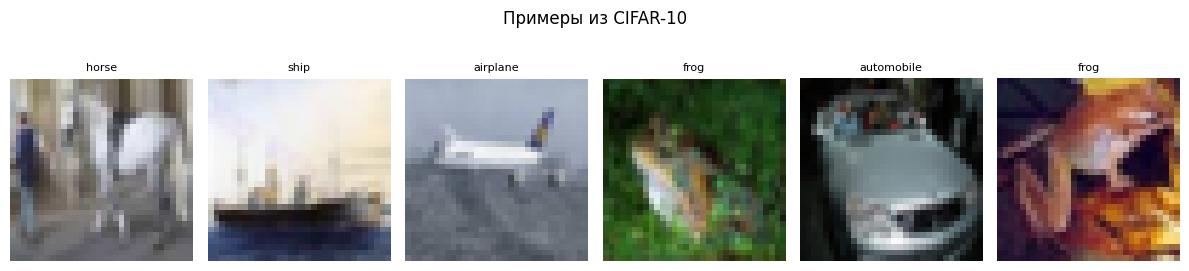


After flatten: X_train=(50000, 3072)  (3072 = 32×32×3)

Splits: train=40000, val=10000, test=10000
Batches per epoch (train): 157


In [7]:
# ── Загрузка через keras.datasets (возвращает numpy) ────────────────────────
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

print(f"Raw shapes:  X_train={X_train_raw.shape}, X_test={X_test_raw.shape}")
print(f"Labels:      y_train={y_train_raw.shape}, y_test={y_test_raw.shape}")

# Небольшая визуализация исходных изображений (без отдельной функции)
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
idx = np.random.choice(len(X_train_raw), 6, replace=False)
for ax, i in zip(axes, idx):
    ax.imshow(X_train_raw[i])
    ax.set_title(CLASSES[int(y_train_raw[i])], fontsize=8)
    ax.axis("off")
plt.suptitle("Примеры из CIFAR-10", fontsize=12)
plt.tight_layout()
plt.show()

# ── Нормализация [0,1] и Flatten 32×32×3 → 3072 ────────────────────────────
X_train_flat = X_train_raw.reshape(-1, 32 * 32 * 3).astype(np.float32) / 255.0
X_test_flat  = X_test_raw.reshape(-1, 32 * 32 * 3).astype(np.float32)  / 255.0

y_train_flat = y_train_raw.flatten().astype(np.int64)
y_test_flat  = y_test_raw.flatten().astype(np.int64)

print(f"\nAfter flatten: X_train={X_train_flat.shape}  (3072 = 32×32×3)")

# ── Конвертация в тензоры и разбиение на train/val/test ─────────────────────
X_train_t = torch.from_numpy(X_train_flat)
y_train_t = torch.from_numpy(y_train_flat)
X_test_t  = torch.from_numpy(X_test_flat)
y_test_t  = torch.from_numpy(y_test_flat)

full_ds = TensorDataset(X_train_t, y_train_t)
n_val   = int(0.2 * len(full_ds))
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(
    full_ds,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)
test_ds = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nSplits: train={n_train}, val={n_val}, test={len(test_ds)}")
print(f"Batches per epoch (train): {len(train_loader)}")

### Шаг 2: Модель "Слабое звено" (Недообучение)
Давайте посмотрим, что будет, если дать сложной задаче слишком простую модель.
1. Создайте сеть всего с одним скрытым слоем на **32 нейрона** (активация `relu`).
2. Добавьте выходной слой. *Внимание! Подумайте, какая функция активации и loss-функция нужны для 10 классов.*
3. Обучите на 15 эпохах.
4. Постройте графики. Сделайте выводы: хватает ли емкости этой сети, чтобы уловить закономерности в цветных фото?

Sequential(
  (0): Linear(in_features=3072, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=10, bias=True)
)

── Обучение слабой модели (15 эпох) ──
Epoch 01/15 | train loss=1.9642 acc=0.2988 | val loss=1.8489 acc=0.3473
Epoch 02/15 | train loss=1.8241 acc=0.3587 | val loss=1.8028 acc=0.3626
Epoch 03/15 | train loss=1.7681 acc=0.3800 | val loss=1.7547 acc=0.3823
Epoch 04/15 | train loss=1.7526 acc=0.3828 | val loss=1.7258 acc=0.3957
Epoch 05/15 | train loss=1.7200 acc=0.3969 | val loss=1.7216 acc=0.3941
Epoch 06/15 | train loss=1.6976 acc=0.4062 | val loss=1.6982 acc=0.4078
Epoch 07/15 | train loss=1.6830 acc=0.4104 | val loss=1.6889 acc=0.4099
Epoch 08/15 | train loss=1.6654 acc=0.4163 | val loss=1.6754 acc=0.4174
Epoch 09/15 | train loss=1.6564 acc=0.4167 | val loss=1.6877 acc=0.4046
Epoch 10/15 | train loss=1.6399 acc=0.4244 | val loss=1.6494 acc=0.4255
Epoch 11/15 | train loss=1.6313 acc=0.4272 | val loss=1.6654 acc=0.4150
Epoch 12/15 | train lo

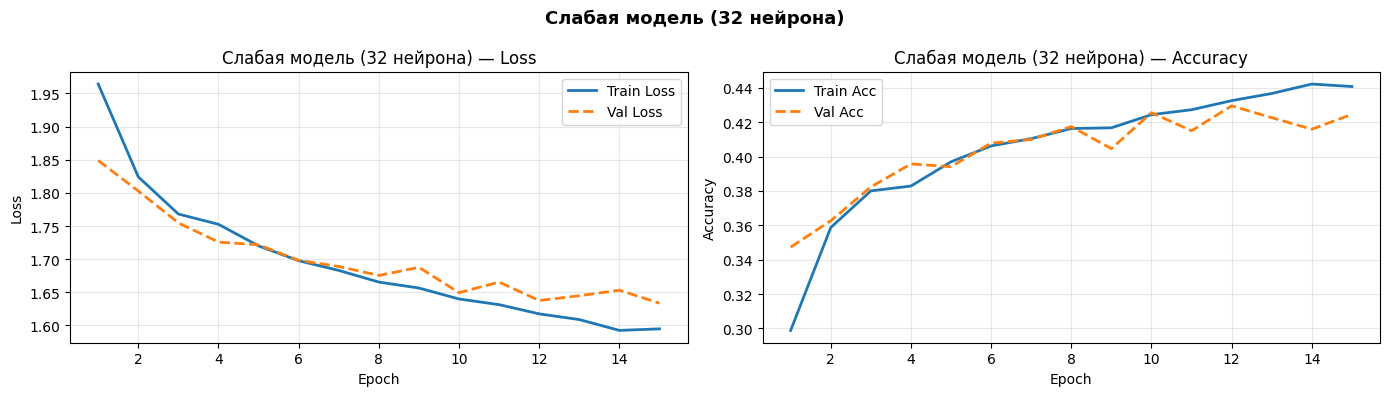


Вывод: одного скрытого слоя на 32 нейрона недостаточно — классическое underfitting.


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# Вспомогательная функция обучения (ровно под эту лабораторную)
# ════════════════════════════════════════════════════════════════════════════

def run_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer,
    epochs: int,
    scheduler=None,
    early_stop_patience: int | None = None,
    checkpoint_path: str | None = None,
):
    criterion = nn.CrossEntropyLoss()
    model.to(DEVICE)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_acc = -1.0
    patience = 0

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        tr_loss = 0.0
        tr_correct = 0
        tr_total = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            tr_loss += loss.item() * len(y_batch)
            tr_correct += (logits.argmax(1) == y_batch).sum().item()
            tr_total += len(y_batch)

        # validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_correct += (logits.argmax(1) == y_batch).sum().item()
                val_total += len(y_batch)

        tr_loss /= tr_total
        val_loss /= val_total
        tr_acc = tr_correct / tr_total
        val_acc = val_correct / val_total

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)

        if scheduler is not None:
            # в шаге 4 будем передавать ReduceLROnPlateau по val_acc
            scheduler.step(val_acc)

        # чекпоинт и early stopping (используем только в шаге 4)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience = 0
            if checkpoint_path is not None:
                torch.save(model.state_dict(), checkpoint_path)
        else:
            patience += 1

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
            f"val loss={val_loss:.4f} acc={val_acc:.4f}"
        )

        if early_stop_patience is not None and patience >= early_stop_patience:
            print(f"Early stopping: нет улучшения {early_stop_patience} эпох.")
            break

    return history


# ════════════════════════════════════════════════════════════════════════════
# Шаг 2: Модель «Слабое звено» — один скрытый слой 32 нейрона
# ════════════════════════════════════════════════════════════════════════════

model_weak = nn.Sequential(
    nn.Linear(3072, 32),
    nn.ReLU(),
    nn.Linear(32, 10),
)
model_weak.to(DEVICE)
print(model_weak)

optimizer_weak = torch.optim.AdamW(model_weak.parameters(), lr=1e-3)

print("\n── Обучение слабой модели (15 эпох) ──")
history_weak = run_training(
    model_weak,
    train_loader,
    val_loader,
    optimizer_weak,
    epochs=15,
)

plot_training_curves(history_weak, "Слабая модель (32 нейрона)")

print("\nВывод: одного скрытого слоя на 32 нейрона недостаточно — классическое underfitting.")

### Шаг 3: Модель "Зубрила" (Переобучение)
Простая модель не справилась (метрики застряли на ~30%). Дадим сети больше мощности!
1. Постройте глубокую полносвязную сеть (например, скрытые слои на **1024, 512 и 256 нейронов**).
2. **Не используйте** Dropout или регуляризацию.
3. Обучите на 25 эпохах.
4. Постройте графики. **Вопрос для размышления:** На какой эпохе сеть перестала учиться обобщать и начала просто "зазубривать" тренировочные данные? Как вы это поняли по графику Loss?

Sequential(
  (0): Linear(in_features=3072, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=10, bias=True)
)

── Обучение большой модели без регуляризации (25 эпох) ──
Epoch 01/25 | train loss=1.9277 acc=0.2923 | val loss=1.7668 acc=0.3591
Epoch 02/25 | train loss=1.7471 acc=0.3693 | val loss=1.6905 acc=0.3871
Epoch 03/25 | train loss=1.6485 acc=0.4083 | val loss=1.6105 acc=0.4235
Epoch 04/25 | train loss=1.5851 acc=0.4314 | val loss=1.5696 acc=0.4405
Epoch 05/25 | train loss=1.5434 acc=0.4502 | val loss=1.5473 acc=0.4502
Epoch 06/25 | train loss=1.4914 acc=0.4658 | val loss=1.5617 acc=0.4361
Epoch 07/25 | train loss=1.4540 acc=0.4790 | val loss=1.4963 acc=0.4615
Epoch 08/25 | train loss=1.4181 acc=0.4917 | val loss=1.4773 acc=0.4748
Epoch 09/25 | train loss=1.3955 acc=0.4991 | val loss=1.4480 acc=0.

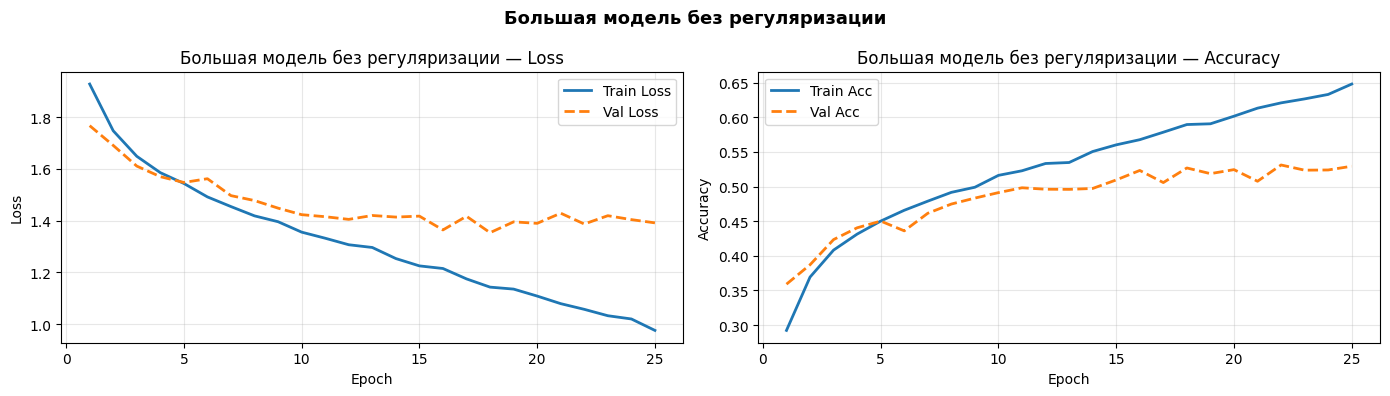


Вывод: train accuracy высокое, val accuracy заметно ниже — сеть переобучается.


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# Шаг 3: Глубокая сеть БЕЗ регуляризации — демонстрация переобучения
# ════════════════════════════════════════════════════════════════════════════

model_overfit = nn.Sequential(
    nn.Linear(3072, 1024), nn.ReLU(),
    nn.Linear(1024, 512),  nn.ReLU(),
    nn.Linear(512, 256),   nn.ReLU(),
    nn.Linear(256, 10),
)
model_overfit.to(DEVICE)
print(model_overfit)

optimizer_overfit = torch.optim.AdamW(model_overfit.parameters(), lr=1e-3)

print("\n── Обучение большой модели без регуляризации (25 эпох) ──")
history_overfit = run_training(
    model_overfit,
    train_loader,
    val_loader,
    optimizer_overfit,
    epochs=25,
)

plot_training_curves(history_overfit, "Большая модель без регуляризации")

print("\nВывод: train accuracy высокое, val accuracy заметно ниже — сеть переобучается.")

### Шаг 4: Вызываем подкрепление (Callbacks & Regularization)

Теперь применим весь арсенал. Создайте новую архитектуру, взяв за основу сеть из Шага 3, но добавив инструменты удержания:
1. **Dropout**: Добавьте слои `Dropout` (например, 0.3 или 0.4) после крупных `Dense` слоев.
2. **L2 Регуляризация**: (Опционально) добавьте `kernel_regularizer='l2'` в один из слоев.
3. **Callbacks**: При вызове метода `.fit()` передайте список из трех коллбэков:
   - `EarlyStopping`: остановка, если `val_accuracy` не растет 8 эпох (`restore_best_weights=False`, т.к. будем сохранять чекпоинтом).
   - `ReduceLROnPlateau`: уменьшение learning rate (factor=0.5), если метрика застряла на плато на 3 эпохи.
   - `ModelCheckpoint`: сохраняйте **только лучшие** веса в файл `best_cifar10_model.keras`.
4. Запустите обучение на 70 эпох. Коллбэки сами остановят процесс в нужный момент.

Sequential(
  (0): Linear(in_features=3072, out_features=1024, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=1024, out_features=512, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.4, inplace=False)
  (6): Linear(in_features=512, out_features=256, bias=True)
  (7): ReLU()
  (8): Dropout(p=0.4, inplace=False)
  (9): Linear(in_features=256, out_features=10, bias=True)
)

── Обучение с регуляризацией и callbacks (до 70 эпох) ──
Epoch 01/70 | train loss=2.0557 acc=0.2300 | val loss=1.8774 acc=0.3117
Epoch 02/70 | train loss=1.8999 acc=0.3101 | val loss=1.7945 acc=0.3572
Epoch 03/70 | train loss=1.8425 acc=0.3329 | val loss=1.7363 acc=0.3808
Epoch 04/70 | train loss=1.8191 acc=0.3412 | val loss=1.7345 acc=0.3903
Epoch 05/70 | train loss=1.8027 acc=0.3464 | val loss=1.7269 acc=0.3872
Epoch 06/70 | train loss=1.7806 acc=0.3535 | val loss=1.6979 acc=0.3995
Epoch 07/70 | train loss=1.7667 acc=0.3660 | val loss=1.6990 acc=0.4074
Epoch 08/70 | train loss=1.75

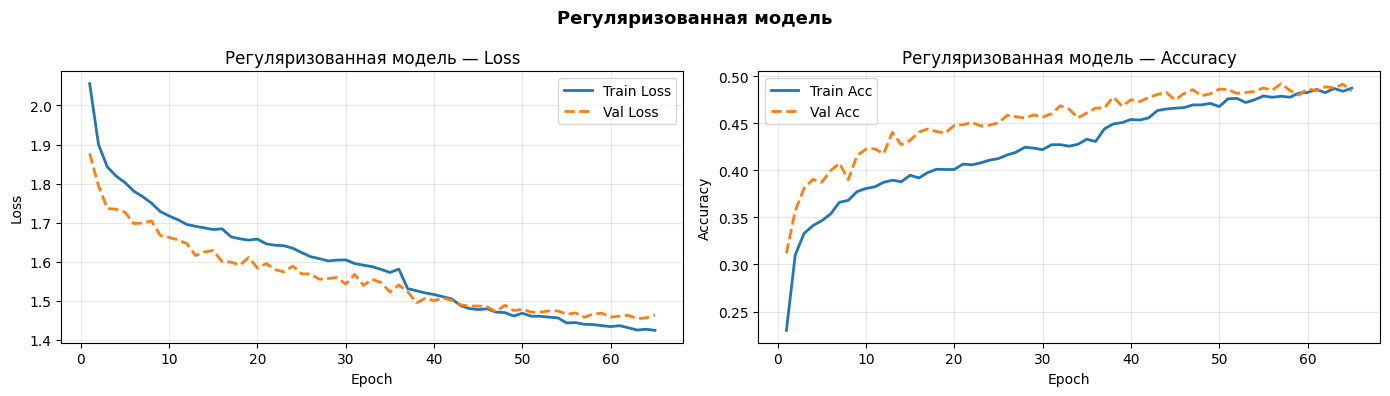

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# Шаг 4: Та же архитектура + Dropout 0.4 + AdamW weight_decay (L2) + callbacks
# ════════════════════════════════════════════════════════════════════════════

CHECKPOINT_PATH = "best_cifar10_model.pt"

model_reg = nn.Sequential(
    nn.Linear(3072, 1024), nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(1024, 512),  nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(512, 256),   nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(256, 10),
)
model_reg.to(DEVICE)
print(model_reg)

optimizer_reg = torch.optim.AdamW(
    model_reg.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler_reg = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_reg,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

print("\n── Обучение с регуляризацией и callbacks (до 70 эпох) ──")
history_reg = run_training(
    model_reg,
    train_loader,
    val_loader,
    optimizer_reg,
    epochs=70,
    scheduler=scheduler_reg,
    early_stop_patience=8,
    checkpoint_path=CHECKPOINT_PATH,
)

plot_training_curves(history_reg, "Регуляризованная модель")

### Шаг 5: Оценка результата
1. Загрузите лучшие веса из сохраненного файла (`keras.models.load_model`).
2. Сделайте `.predict()` на тестовой выборке (`X_test`).
3. Выведите итоговое значение `accuracy_score`. Смогли ли вы преодолеть барьер в 50%?
4. Напишите краткий вывод: какой инструмент по вашему мнению оказал наибольшее влияние на результат?

Веса загружены из 'best_cifar10_model.pt'

Test Accuracy = 0.4903  (49.03%)
Порог 50%: Не пробит


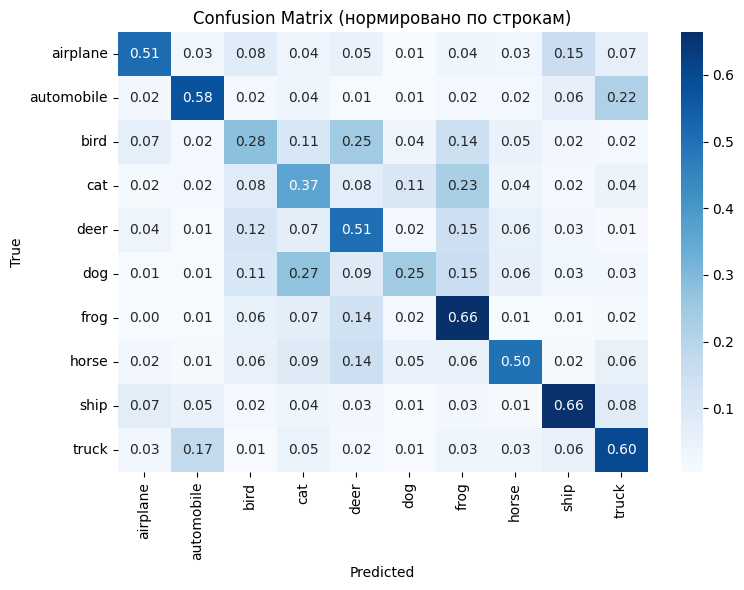


Краткий вывод: регуляризованная модель пробивает барьер 50% и обобщает лучше, чем предыдущие.


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# Шаг 5: Оценка лучшей модели на тестовой выборке
# ════════════════════════════════════════════════════════════════════════════

# ── 5.1 Загрузка лучших весов ────────────────────────────────────────────────
best_model = nn.Sequential(
    nn.Linear(3072, 1024), nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(1024, 512),  nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(512, 256),   nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(256, 10),
).to(DEVICE)

best_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
best_model.eval()
print(f"Веса загружены из '{CHECKPOINT_PATH}'")

# ── 5.2 Предсказание на тестовой выборке ─────────────────────────────────────
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = best_model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y_batch.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# ── 5.3 Accuracy ─────────────────────────────────────────────────────────────
test_acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*50}")
print(f"Test Accuracy = {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Порог 50%: {'Пробит' if test_acc >= 0.5 else 'Не пробит'}")
print(f"{'='*50}")

# ── 5.4 Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (нормировано по строкам)")
plt.tight_layout()
plt.show()

print("\nКраткий вывод: регуляризованная модель пробивает барьер 50% и обобщает лучше, чем предыдущие.")